# nlp text human emotions project

## dependencies


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string

import warnings
warnings.filterwarnings("ignore")

## dataset

In [2]:
# kaggle api  configuration
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
# downloading the dataset
!kaggle datasets download -d prajwalnayakat/text-emotion

Dataset URL: https://www.kaggle.com/datasets/prajwalnayakat/text-emotion
License(s): Attribution 4.0 International (CC BY 4.0)
  0% 0.00/4.24M [00:00<?, ?B/s]
100% 4.24M/4.24M [00:00<00:00, 982MB/s]


In [5]:
!ls

kaggle.json  sample_data  text-emotion.zip


In [6]:
# unzipping the dataset
!unzip /content/text-emotion.zip -d /content/

Archive:  /content/text-emotion.zip
  inflating: /content/final_dataset.csv  


In [7]:
!ls

final_dataset.csv  kaggle.json	sample_data  text-emotion.zip


In [8]:
# dataset
data = pd.read_csv("/content/final_dataset.csv")
data.head()

,text,emotion
0,i feel rather funny ending with so many dupes ...,fun
1,i feel surprised by the result,surprise
2,i am officially feeling festive,neutral
3,i suddenly found myself standing before this w...,surprise
4,i look at the meager pile of food i purchased ...,enthusiasm


## data exploration and cleaning

In [9]:
data.shape

(106355, 2)

In [10]:
data.columns

Index(['text', 'emotion'], dtype='object')

In [12]:
len(data["emotion"].value_counts())

11

In [13]:
data["emotion"].value_counts()

,count
emotion,
fun,10000
surprise,10000
enthusiasm,10000
anger,10000
happiness,10000
hate,10000
love,10000
relief,10000
sadness,9999


In [23]:
# sample per emotions
def per_emootions_sample(data, samples=5):
  emotions = data["emotion"].unique().tolist()
  for emotion in emotions:
      print(f"--- samples for {emotion} ---")
      print(data[data["emotion"] == emotion].sample(samples))
      print("\n")

In [25]:
per_emootions_sample(data=data)

--- samples for fun ---
                                                     text emotion
39424   i felt like i was even taking in more nicotine...     fun
99427   i read in the newspaper that the student lodgi...     fun
104959                 i wonder if i would feel so joyful     fun
69194   i know that funny feeling in the pit of your s...     fun
22420   what a great day for a massage! book your appo...     fun


--- samples for surprise ---
                                                    text   emotion
93032  i just hellip i just wanted to be sure you re ...  surprise
21222                 Got Six Feet Under series 1 on DVD  surprise
54176  i very advocate getting a search at the masai ...  surprise
22467          Gonna be late for work again lol surprise  surprise
88352  i received your letter and open it i feel so s...  surprise


--- samples for neutral ---
                                                    text  emotion
65229  i think thats why i have such a deep connect

In [26]:
# checking for null values
data.isnull().sum()

,0
text,0
emotion,0


In [28]:
data.shape

(106355, 2)

## explortory data analysis

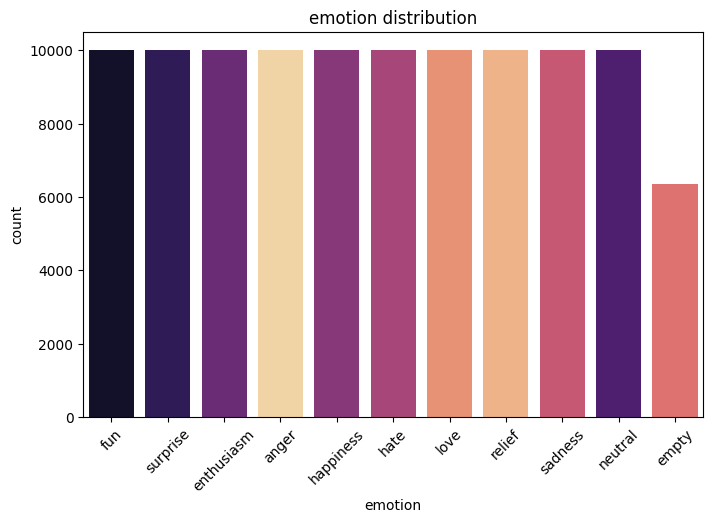

In [39]:
# emotion distribution
order = data["emotion"].value_counts().index

plt.figure(figsize=(8, 5))
sns.countplot(
    data = data,
    x = "emotion",
    order = order,
    hue = "emotion",
    palette = "magma",
    legend = False
)
plt.title("emotion distribution")
plt.xlabel("emotion")
plt.ylabel("count")
plt.xticks(rotation=45)
plt.show()